## Title: _____?

## Introduction

The gaming industry has increasingly relied on player analytics to understand user behaviour, personalize in-game experiences, and design effective marketing strategies. One area of particular interest is identifying what factors influence whether players choose to engage with optional game-related content, such as newsletters. Newsletters serve as an important communication channel for game developers, often used to share updates, promote new features, and foster long-term player engagement. Understanding which types of players are most likely to subscribe can help developers tailor outreach efforts and improve player retention.

The goal of this project is to investigate whether a player’s age and total playtime are associated with their likelihood of subscribing to the game’s newsletter. In other words, we ask:

### Research Question:
Can a player’s age and total playtime help explain patterns in who subscribes to the game’s newsletter?

To answer this question, we analyzed the players.csv dataset provided. This dataset contains anonymized information on 196 players, including demographic features and in-game behavioural metrics. The relevant variables for this study include:

age: The player’s age in years.

total_playtime: A numeric measure representing the player’s total hours or session-time spent in the game.

subscribed: A logical (TRUE/FALSE) indicator of whether the player is subscribed to the newsletter.

Additional variables such as session timestamps and player identifiers were included in the raw dataset but not directly used in the final analysis after exploratory review.

Before conducting modeling, we performed data cleaning and exploratory data analysis to understand variable distributions, assess potential limitations such as missing values or imbalance in the subscription variable, and generate visualizations that guide the methodological choices of the study. Because the response variable, subscribed, is binary, we use statistical modeling techniques suitable for classification tasks to evaluate whether age and playtime meaningfully predict subscription behaviour.

This analysis contributes to a broader understanding of player engagement by exploring whether simple, readily collected metrics (age and playtime) contain useful predictive patterns. If such relationships exist, they may inform targeted communication strategies, help identify under-engaged groups of players, and shape future data-driven decisions in game development and marketing.

## Methods and Results


In [6]:
library(tidyverse)

url <- "https://raw.githubusercontent.com/cassidoi/dsci-100-2025w1-group36-cassidy/refs/heads/main/players.csv"
players <- read_csv(url)

head(players)


Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


### Data Wrangling and Cleaning

Before conducting exploratory analysis, we prepared the dataset for modeling. 
The raw `players` data contains seven variables:

- `experience`: A categorical skill-level label (Amateur, Regular, Veteran, etc.)
- `subscribe`: A logical indicator of whether the player subscribed to the newsletter.
- `hashedEmail`: A unique, anonymized identifier for each player.
- `played_hours`: A numeric measure of total gameplay time.
- `name`: Player names (not analytically relevant).
- `gender`: Self-reported gender.
- `Age`: Player age in years.

Because our research question focuses on whether *age* and *total playtime* predict *subscription status*, we selected only the variables relevant to this relationship.  
We also standardized column names for readability, checked for missing values, and removed non-predictive identifiers such as `name` and `hashedEmail`.  
Finally, because tidymodels requires the outcome variable to be a **factor** for classification, we converted the `subscribed` column from a logical value to a factor.



In [45]:
players_clean <- players |>
  rename(age = Age, subscribed = subscribe, playtime = played_hours) |>
  select(age, playtime, subscribed, experience, gender) |>
  drop_na() |>
  mutate(subscribed = factor(subscribed))

glimpse(players_clean)

Rows: 194
Columns: 5
$ age        <dbl> 9, 17, 17, 21, 21, 17, 19, 21, 47, 22, 23, 17, 25, 22, 17, …
$ playtime   <dbl> 30.3, 3.8, 0.0, 0.7, 0.1, 0.0, 0.0, 0.0, 0.1, 0.0, 1.6, 0.0…
$ subscribed <fct> TRUE, TRUE, FALSE, TRUE, TRUE, TRUE, TRUE, FALSE, TRUE, TRU…
$ experience <chr> "Pro", "Veteran", "Veteran", "Amateur", "Regular", "Amateur…
$ gender     <chr> "Male", "Male", "Male", "Female", "Male", "Female", "Female…


### Exploratory Data Analysis: Summary Statistics

Before visualizing the data, we computed summary statistics to understand the basic structure of the dataset. Since our analysis focuses on whether age and total playtime help explain newsletter subscription behavior, the summary emphasizes these variables. 

We calculated overall measures of central tendency and spread for `age` and `playtime`, as well as the proportion of players who subscribed to the newsletter. To explore potential differences between groups, we also computed summary statistics for each variable by subscription status. These summaries help assess whether age or playtime appear to differ meaningfully between subscribed and unsubscribed players prior to formal modeling.


In [47]:
players_clean |>
  summarize(
    mean_age = mean(age),
    median_age = median(age),
    sd_age = sd(age),
    min_age = min(age),
    max_age = max(age),
    
    mean_playtime = mean(playtime),
    median_playtime = median(playtime),
    sd_playtime = sd(playtime),
    min_playtime = min(playtime),
    max_playtime = max(playtime)
  )

players_clean |>
  count(subscribed) |>
  mutate(prop = n / sum(n))

players_clean |>
  group_by(subscribed) |>
  summarize(mean_age = mean(age),
    median_age = median(age),
    mean_playtime = mean(playtime),
    median_playtime = median(playtime),
    .groups = "drop")


mean_age,median_age,sd_age,min_age,max_age,mean_playtime,median_playtime,sd_playtime,min_playtime,max_playtime
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21.13918,19,7.389687,9,58,5.904639,0.1,28.49793,0,223.1


subscribed,n,prop
<fct>,<int>,<dbl>
FALSE,52,0.2680412
TRUE,142,0.7319588


subscribed,mean_age,median_age,mean_playtime,median_playtime
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,23.7500,21,0.5019231,0.0
TRUE,20.1831,19,7.8830986,0.1


### Exploratory Data Analysis: Visualizations

To better understand the distribution of the key predictors, we visualized the distributions of `age` and `playtime`, as well as the proportion of players who subscribed to the newsletter. These plots help identify skewness, group imbalance, and potential nonlinear patterns that may influence the modeling stage.


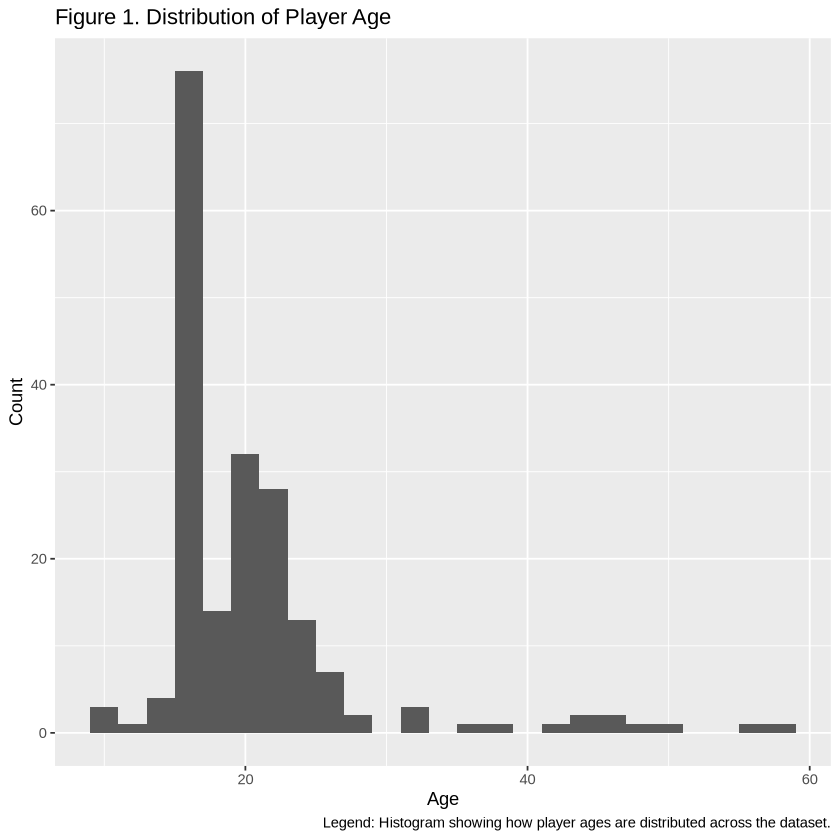

In [9]:
ggplot(players_clean, aes(x = age)) +
  geom_histogram(binwidth = 2) +
  labs(title = "Figure 1. Distribution of Player Age", x = "Age",y = "Count", caption = "Legend: Histogram showing how player ages are distributed across the dataset.")


talk abt what we see

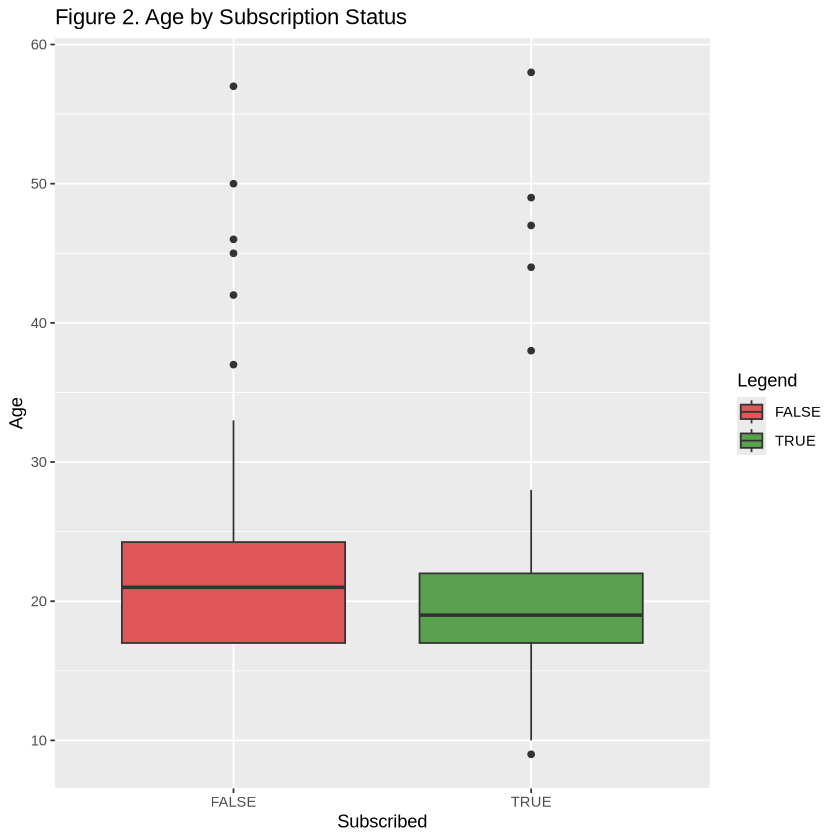

In [11]:
ggplot(players_clean, aes(x = subscribed, y = age, fill = subscribed)) +
  geom_boxplot() +
  scale_fill_manual(values = c("FALSE" = "#E15759", "TRUE" = "#59A14F"), name = "Legend") +
  labs(title = "Figure 2. Age by Subscription Status", x = "Subscribed",y = "Age") +
  theme(legend.position = "right")


talk about what we see

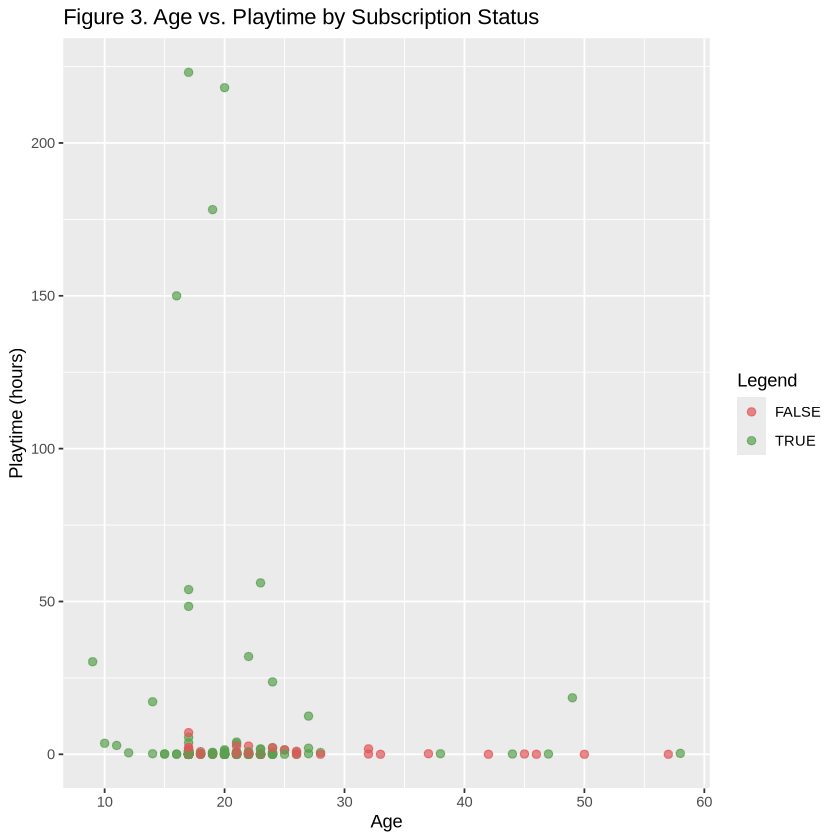

In [12]:
ggplot(players_clean, aes(x = age, y = playtime, color = subscribed)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_manual(values = c("FALSE" = "#E15759", "TRUE" = "#59A14F"), name = "Legend") +
  labs(title = "Figure 3. Age vs. Playtime by Subscription Status",x = "Age",y = "Playtime (hours)") 
# coord_cartesian(ylim = c(0, quantile(players_clean$playtime, 0.95))) (idk if we want this)



talk about what we see

## Discussion

add discussion here

## Train-Test Split

To prepare the data for modelling, we split `players_clean` into two sets: a training set (75% of observations) and a test set (25%), separated according to `subscribed` such that both sets kept the proportion of subscribers and non-subscribers.  This allows us to train the KNN classifier on one part of data while fairly evaluating its performance on unseen players on the other sample.

In [73]:
player_split <- initial_split(players_clean, prop = 0.75, strata = subscribed)

train <- training(player_split)
test  <- testing(player_split)

head(train)
head(test)

age,playtime,subscribed,experience,gender
<dbl>,<dbl>,<fct>,<chr>,<chr>
17,0.0,FALSE,Veteran,Male
21,0.0,FALSE,Amateur,Male
17,0.1,FALSE,Amateur,Female
23,0.0,FALSE,Veteran,Male
25,1.4,FALSE,Veteran,Prefer not to say
24,0.0,FALSE,Beginner,Male


age,playtime,subscribed,experience,gender
<dbl>,<dbl>,<fct>,<chr>,<chr>
17,3.8,TRUE,Veteran,Male
21,0.1,TRUE,Regular,Male
22,0.0,TRUE,Veteran,Female
22,0.0,FALSE,Amateur,Male
58,0.3,TRUE,Regular,Male
21,0.7,TRUE,Amateur,Female


## Preprocessing Recipe

 Before fitting the KNN classifier, we built a preprocessing recipe for standardizing the numeric predictors used in the model.  Because KNN relies on distance computations, variables with bigger scales could overpower the distance measure, so we normalized `age` and `playtime` to place them on comparable scales.  This recipe was created using training data, so that all preprocessing procedures were learned exclusively from the training set and performed identically to the test set.

In [72]:
player_recipe <- recipe(subscribed ~ age + playtime, data = train) |>
step_center(all_predictors()) |>
step_scale(all_predictors())

player_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Centering for: all_predictors()

• Scaling for: all_predictors()



### KNN Model Specifications and Workflow

We created a K-nearest neighbours (KNN) classification model to determine if a player subscribed to the newsletter using `age` and `playtime` as predictors.  In this model, the number of neighbours \(K\) was treated as a tuning parameter. We could later begin looking for the value of \(K\) that offered the highest performance.

We then immediately combined the preprocessing recipe with the KNN model to create a single `workflow`.  This guaranteed that centering, scaling, and model fitting were done concurrently, and that the same preprocessing processes were used identically across all resamples and the test set.

In [71]:
knn_spec <- nearest_neighbor(weight_func = "rectangular",neighbors = tune()) |>
set_engine("kknn") |>
set_mode("classification")

player_workflow <- workflow() |>
add_recipe(player_recipe) |>
add_model(knn_spec)

player_workflow

══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_center()
• step_scale()

── Model ───────────────────────────────────────────────────────────────────────
K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


## Cross-Validation Setup

Before tuning the KNN classifier, we made a 5-fold cross-validation object using the training data.  Cross-validation helped us to more accurately assess model performance by fitting the model to multiple subsets of the training data while leaving the test set alone.  We chose \(K\) based on consistent performance over several resamples.



In [70]:
player_folds <- vfold_cv(train, v = 5, strata = subscribed)
#We did not print the `player_folds` object as cross-validation folds include large resampling structures that produce long console outputs in Jupyter.  This has no effect on the modelling process because the folds were correctly constructed and tuned.

### Tuning the Number of Neighbours (K)

We used 5-fold cross-validation on the training data to tune the K-nearest neighbours classifier.  For each candidate value of \(K\), we fitted the model on the resampled training folds and recorded its classification performance. This allowed us to determine which value of \(K\) performed best overall.

In [69]:
k_grid <- tibble(neighbors = seq(1, 25, by = 2))

knn_results <- tune_grid(player_workflow,resamples = player_folds,grid = k_grid)
collect_metrics(knn_results)


neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.4832348,5,0.034114623,Preprocessor1_Model01
1,roc_auc,binary,0.5180736,5,0.027502995,Preprocessor1_Model01
3,accuracy,binary,0.5174877,5,0.022528532,Preprocessor1_Model02
3,roc_auc,binary,0.5483264,5,0.037582014,Preprocessor1_Model02
5,accuracy,binary,0.6476683,5,0.040565352,Preprocessor1_Model03
5,roc_auc,binary,0.5654646,5,0.052184504,Preprocessor1_Model03
7,accuracy,binary,0.6752217,5,0.050526217,Preprocessor1_Model04
7,roc_auc,binary,0.5388180,5,0.043575867,Preprocessor1_Model04
9,accuracy,binary,0.6749754,5,0.026642187,Preprocessor1_Model05


### Choosing the Best Number of Neighbours

 Based on the tuning results, we chose the value of \(K\) with the highest cross-validated **accuracy** on the training folds.  We saved the best value of \(K\) and used it to wrap up our KNN model in our next section.

In [68]:
best_k <- select_best(knn_results, metric = "accuracy")
best_k


neighbors,.config
<dbl>,<chr>
11,Preprocessor1_Model06


## Finalizing the KNN Model

 We finished our KNN workflow through putting the optimal tuning value of \(K\) into the model.  We then fit the finished model to the entire training set to ready it for evaluation on the remaining test set.

In [67]:
final_knn_workflow <- finalize_workflow(player_workflow, best_k)

final_knn_fit <- fit(final_knn_workflow, data = train)
final_knn_fit


══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_center()
• step_scale()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(11,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2551724
Best kernel: rectangular
Best k: 11

### Evaluating the Final KNN Model on the Test Set

After training the finished KNN model on the entire training data set, we assessed its performance on the remaining test set.  We created class predictions for each player in the test set and then computed summary metrics, with a focus on overall accuracy, to see how effectively the model adapts to new data.

In [66]:
preds <- predict(final_knn_fit, test)

final_knn_predictions <- bind_cols(preds, test)

knn_test_metrics <- metrics(final_knn_predictions,truth = subscribed, estimate = .pred_class)
knn_test_metrics


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.67346939
kap,binary,0.07109005


### Accuracy vs. Number of Neighbours (K)

To understand how the choice of \(K\) influences the performance of our KNN
classifier, we plotted the cross-validated accuracy for each K value that was
tested during tuning.  This representation helps us recognize which neighbourhood
size produced the most accuracy on the training folds.

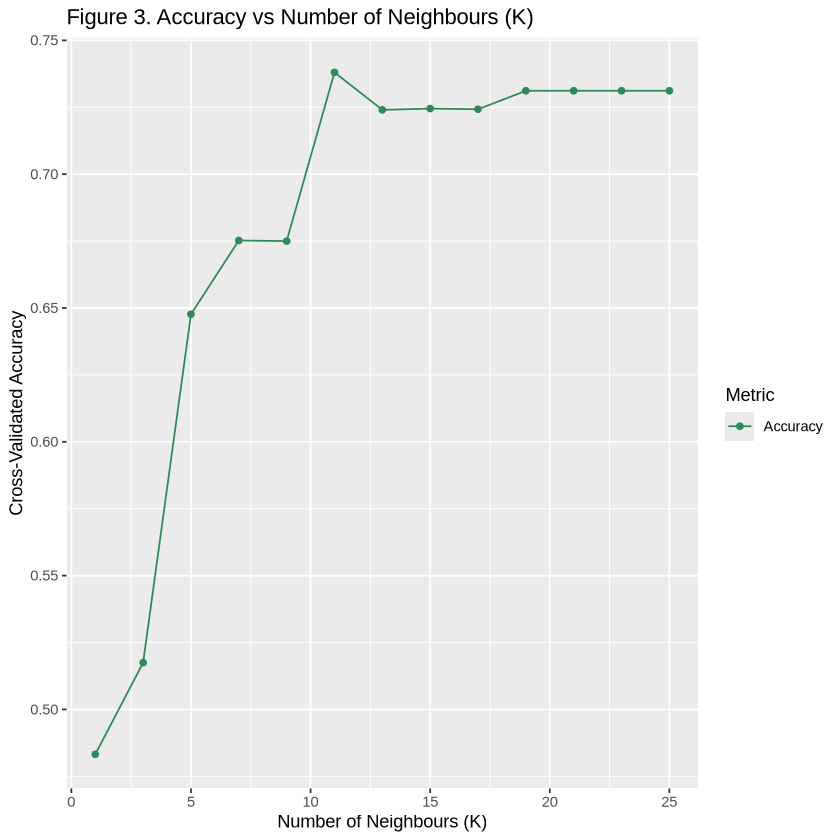

In [77]:
knn_metrics <- knn_results |> collect_metrics()

knn_acc <- knn_metrics |> filter(.metric == "accuracy")

accuracy_vs_k <- ggplot(knn_acc, aes(x = neighbors, y = mean, color = "Accuracy", group = 1)) +
geom_point() +
geom_line() +
labs(title = "Figure 3. Accuracy vs Number of Neighbours (K)",x = "Number of Neighbours (K)",y = "Cross-Validated Accuracy",color = "Metric") +
scale_color_manual(values = c("Accuracy" = "seagreen")) +
theme(legend.position = "right")

accuracy_vs_k

## Confusion Matrix for the Test Set

We examined the performance of our finished KNN model on the remaining test set, after training it on the full training data.  To better explain classification errors, we created a confusion matrix.  The table displays how many players were properly or wrongly predicted as subscribers to newsletters versus non-subscribers.

In [64]:
preds <- predict(final_knn_fit, test)

final_knn_predictions <- bind_cols(preds, test)

knn_conf_mat <- conf_mat(final_knn_predictions,truth = subscribed,estimate = .pred_class)

knn_conf_mat

          Truth
Prediction FALSE TRUE
     FALSE     3    6
     TRUE     10   30